In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Sha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Sha\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Sha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
df = pd.read_csv('Amazon_sentiment_analysis.csv')

Explor Data

In [3]:
df.shape[0]

40000

In [4]:
df.columns

Index(['Unnamed: 0', 'marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date'],
      dtype='object')

In [5]:
df.shape

(40000, 16)

In [7]:
df.head()

,Unnamed: 0,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,0,US,45283875,R131LUTLVH63V2,B003FGWF04,645498686,HH54VP series,Electronics,5.0,0.0,0.0,N,Y,Works GREAT !! Easy to program for home or mob...,Works GREAT !! Easy to program for home or mob...,2015-02-06
1,1,US,23457831,R1NUKNPRX36HIX,B00JAAJ1F6,374159046,Jarv NMotion Sport Wireless Bluetooth 4.0 Ster...,Electronics,5.0,0.0,0.0,N,Y,Best Bang for Your Buck in Wireless Headphones...,Best purchase of my life. These headphones boa...,2015-05-15
2,2,US,6731054,R1VSYY38KIHPIH,B00NM4LKJG,154075815,AUSDOM M04S Over Ear Bluetooth Headphone Advan...,Electronics,5.0,1.0,1.0,N,Y,Awesome!!,Perfect my daughter love them!!!,2014-12-31
3,3,US,46880374,R3RGO8LHIKB1SF,B00ICV26DS,522586369,"Beats by Dr.Dre in Ear Head Phones, Black",Electronics,5.0,0.0,0.0,N,Y,Five Stars,Yes they did.,2014-11-30
4,4,US,34512918,R27W2ZQJOZEH3V,B0046H8ZHS,335809885,SleepPhones Classic Sleep Headphones,Electronics,5.0,0.0,0.0,N,Y,Five Stars,This has made all the difference for me with r...,2015-05-17


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         40000 non-null  int64  
 1   marketplace        40000 non-null  object 
 2   customer_id        40000 non-null  int64  
 3   review_id          40000 non-null  object 
 4   product_id         40000 non-null  object 
 5   product_parent     40000 non-null  int64  
 6   product_title      40000 non-null  object 
 7   product_category   40000 non-null  object 
 8   star_rating        40000 non-null  float64
 9   helpful_votes      40000 non-null  float64
 10  total_votes        40000 non-null  float64
 11  vine               40000 non-null  object 
 12  verified_purchase  40000 non-null  object 
 13  review_headline    39998 non-null  object 
 14  review_body        39989 non-null  object 
 15  review_date        39997 non-null  object 
dtypes: float64(3), int64(3

In [7]:
cols = df.columns
for col in cols :
    print(df[col].isnull().sum())

0
0
0
0
0
0
0
0
0
0
0
0
0
2
11
3


In [8]:
df['star_rating'].value_counts()

star_rating
5.0    16107
1.0     9500
3.0     6116
2.0     4384
4.0     3893
Name: count, dtype: int64

In [9]:
df['star_rating'].unique()

array([5., 4., 1., 2., 3.])

In [10]:
df['vine'].unique()

array(['N', 'Y'], dtype=object)

In [11]:
df['verified_purchase'].unique()

array(['Y', 'N'], dtype=object)

Data Cleaning

In [12]:
#remove any row that contains at least one missing column

df = df.dropna()

In [13]:
#convert float64 type into int64 type

df['star_rating'] = df['star_rating'].astype(float).astype(int)
df['helpful_votes'] = df['helpful_votes'].astype(float).astype(int)
df['total_votes'] = df['total_votes'].astype(float).astype(int)

In [14]:
#convert review_date into datetime format

df['review_date'] = pd.to_datetime(df['review_date'])

Preprocessing Data

In [17]:
#drop unusefull features

col_to_drop = ['Unnamed: 0' , 'marketplace', 'review_id', 'customer_id', 'product_parent','product_id', 'product_title']
df.drop(col_to_drop, axis=1, inplace=True)

In [18]:
#encode categorical values to numercial values

cols_to_encode = ['vine', 'verified_purchase']
for col in cols_to_encode:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

In [20]:
#generate compound score according to review_body column

analyzer = SentimentIntensityAnalyzer()
df['compound'] = df['review_body'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

In [21]:
#convert compound score into labels

df['compound_label'] = df['compound'].apply(lambda score: 1 if score > 0 else 0)

In [22]:
for i in range(10) :
    print(i)
    print(df['review_body'][i])
    

0
Works GREAT !! Easy to program for home or mobile.
1
Best purchase of my life. These headphones boast so much acoustic noise canceling that it's almost a distraction at work. They hold a charge for at least 4 hours, all while my iPhone is charging and I have tunes and podcasts without worrying about my iPhone battery life. Charge the headphones during lunch and I have wireless sound all day (10+ hours). Buying my second pair now, as my last pair went through the wash twice (survived the first time, second killed 'em).<br /><br />Love these headphones and recommend them to all my coworkers.
2
Perfect my daughter love them!!!
3
Yes they did.
4
This has made all the difference for me with respect to my spouse's snoring.
5
Bought two of these. Heavy duty and includes cable and magnetic level. Great comparably for the price.
6
The stranded wires are not as heavy gauge as I would have liked. But all in all, it was quite workable for the price and my purposes (power cable for 4 x 1.2V NiMH 

In [24]:
def lowercasing_text(text) :

    lower_text = text.lower()
    return lower_text


In [25]:
def clean_text(text):
    
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[\W_]+', ' ', text)
    clean_text = re.sub(r'\s+', ' ', text).strip()
    return clean_text

In [26]:
def tokenize_text(text) :

    tokens = word_tokenize(text)
    tokenized_text = [token for token in tokens]
    join_text = ' '.join(tokenized_text)
    return join_text


In [27]:
def remove_stopWords(text) :

    stop_words = set(stopwords.words('english'))
    tokens =  word_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words]
    join_text = ' '.join(tokens)
    return join_text

In [28]:
def lemmatize_text(text) :

    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    lemmatized_text = [lemmatizer.lemmatize(token) for token in tokens]
    join_text = ' '.join(lemmatized_text)
    return join_text

In [29]:
#lowercase 

df['review_body'] = df['review_body'].apply(lowercasing_text)

In [30]:
#Remove HTML tags, URLs, puncuations and underscores

df['review_body'] = df['review_body'].apply(clean_text)

In [31]:
#tokenize

df['review_body'] = df['review_body'].apply(tokenize_text)

In [32]:
#remove stopwords

df['review_body'] = df['review_body'].astype(str).apply(remove_stopWords)

In [33]:
#lemmatize 

df['review_body'] = df['review_body'].astype(str).apply(lemmatize_text)

In [34]:
for i in range(10) :
    print(i)
    print(df['review_body'][i])

0
work great easy program home mobile
1
best purchase life headphone boast much acoustic noise canceling almost distraction work hold charge least 4 hour iphone charging tune podcasts without worrying iphone battery life charge headphone lunch wireless sound day 10 hour buying second pair last pair went wash twice survived first time second killed em love headphone recommend coworkers
2
perfect daughter love
3
yes
4
made difference respect spouse snoring
5
bought two heavy duty includes cable magnetic level great comparably price
6
stranded wire heavy gauge would liked quite workable price purpose power cable 4 x 1 2v nimh battery pack good soldering job followed shrink tubing electrical tape made sturdy
7
great quality dvd sharp picture
8
great cousin hook speaker dj gig bringing huge cable lol light weight black thick long great sound quality
9
sound great especially size love take little space desk yet delivers great sound wish turned automatically turn computer would turn use 30 th

In [35]:
def map_sentiment(star) :

    if star <= 3 :
        return "negative"
    else :
        return "positive"

In [36]:
#convert star_rating into sentiement labels

df['star_rating_label'] = df['star_rating'].apply(map_sentiment)

In [41]:
tfidf = TfidfVectorizer(
    max_features=5000,     
    stop_words='english',    
    ngram_range=(1, 2)       
)


In [42]:
#generate TF_IDF matrix for review_body

X_tfidf = tfidf.fit_transform(df['review_body'])


Data Visualizaing

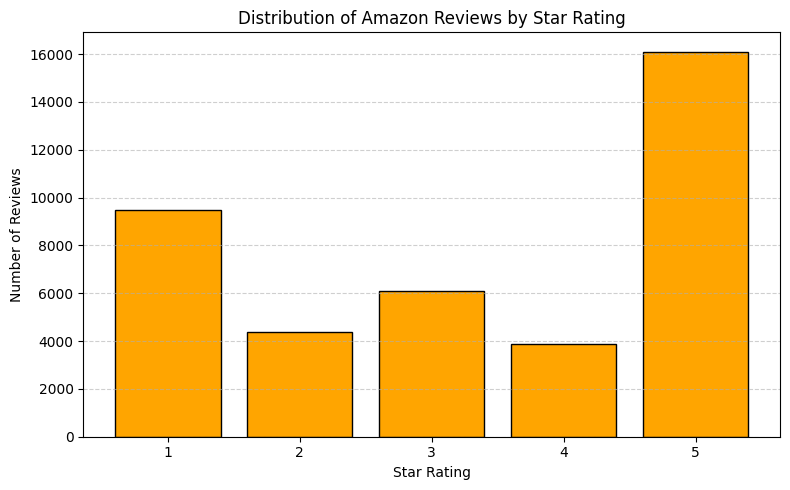

In [37]:
rating_counts = df['star_rating'].value_counts().sort_index()


plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index.astype(str), rating_counts.values, color='orange', edgecolor='black')


plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Amazon Reviews by Star Rating')
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

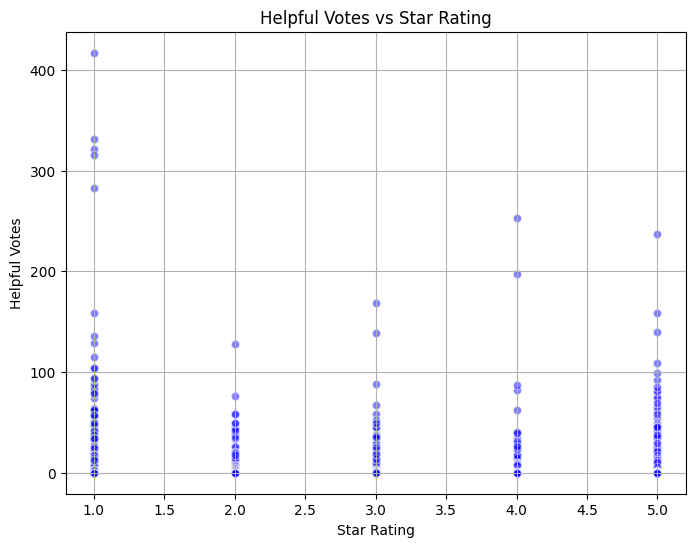

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(df['star_rating'], df['helpful_votes'], alpha=0.5, c='blue', edgecolors='w')


plt.xlabel('Star Rating')
plt.ylabel('Helpful Votes')
plt.title('Helpful Votes vs Star Rating')
plt.grid(True)


plt.show()

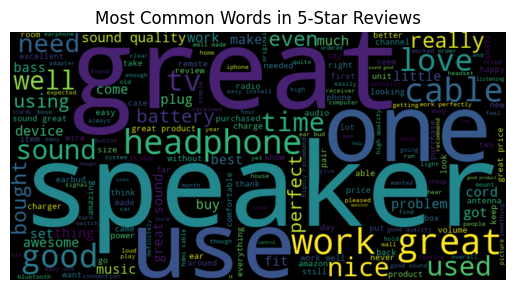

In [39]:
text_5star = " ".join(df[df['star_rating'] == 5]['review_body'])
wordcloud = WordCloud(width=800, height=400).generate(text_5star)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in 5-Star Reviews")
plt.show()